# ÉquiAlgo: corrected model

**Team PolyFinances**

We compare **five families of trained models**, each with a parameter that we sweep to trace a Pareto front:

| # | Family | Principle | Swept parameter |
|---|---|---|---|
| A | Production random forest | reproduces the committee | none (reference) |
| B | Fairness through unawareness | drops region, postal code, then every proxy | variables removed |
| C | `ThresholdOptimizer` (fairlearn) | group-specific thresholds after training | constraint tolerance |
| D | `ExponentiatedGradient` (fairlearn) | retrains under an equal-opportunity constraint | ε |
| E | **Neutralized model (ours)** | learns the committee's rule **with** the bias terms, then switches them off at prediction time | λ, the share of bias kept |

Everything is evaluated on the 4,000 candidates against the **merit standard** defined in `audit_rapport.ipynb`
(R score + 0.146 × hours, top 39.75%), and confirmed against the hidden reference via HxBuddy where possible.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity, DemographicParity

import equialgo as eq

demandes, candidats = eq.charger()
y_hist = demandes['decision_octroi']
el = candidats['eloignee'].values
merite = eq.octroyer_top(eq.score_merite(candidats))  # evaluation standard

CAT = ['programme_etudes', 'region_administrative', 'code_postal_3']
NUM = ['cote_r_equivalent', 'heures_travail_semaine', 'revenu_familial_estime',
       'distance_domicile_campus_km', 'premiere_generation_universitaire']

def matrice(exclure=()):
    """One-hot matrices (historical, candidates) without the excluded columns."""
    cols = [c for c in NUM + CAT if c not in exclure]
    cat = [c for c in CAT if c in cols]
    Xh = pd.get_dummies(demandes[cols], columns=cat, dtype=float)
    Xc = pd.get_dummies(candidats[cols], columns=cat, dtype=float).reindex(columns=Xh.columns, fill_value=0)
    return Xh, Xc

resultats = []
def evaluer(famille, reglage, pred):
    pred = np.asarray(pred).astype(int)
    r = {'family': famille, 'setting': reglage, 'grant_rate': pred.mean(),
         'rate_centres': pred[el == 0].mean(), 'rate_remote': pred[el == 1].mean(),
         'eo_gap': eq.ecart_egalite_chances(merite, pred, el),
         'parity_gap': eq.ecart_parite(pred, el),
         'merit_agreement': (pred == merite).mean(),
         'budget_ok': eq.BUDGET_MIN <= pred.mean() <= eq.BUDGET_MAX}
    resultats.append(r)
    return r

## A. Production model (reference)

In [2]:
Xh, Xc = matrice()
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1).fit(Xh, y_hist)
proba_rf = rf.predict_proba(Xc)[:, 1]
evaluer('A. Production RF', 'all features', rf.predict(Xc))
pd.DataFrame(resultats).round(3)

,family,setting,grant_rate,rate_centres,rate_remote,eo_gap,parity_gap,merit_agreement,budget_ok
0,A. Production RF,all features,0.391,0.469,0.278,0.289,0.191,0.901,True


## B. Fairness through unawareness

We remove the sensitive variable, then its proxies one by one. The model is still trained on the biased labels.

In [3]:
etapes = [
    ('without region', ['region_administrative']),
    ('- postal code', ['region_administrative', 'code_postal_3']),
    ('- distance', ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km']),
    ('- income', ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km', 'revenu_familial_estime']),
    ('- hours (R + program + 1st gen)', ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km',
                                         'revenu_familial_estime', 'heures_travail_semaine']),
]
for nom, excl in etapes:
    Xh_b, Xc_b = matrice(excl)
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1).fit(Xh_b, y_hist)
    # budget fixed at the merit rate so that only the ranking is compared
    evaluer('B. Unawareness', nom, eq.octroyer_top(m.predict_proba(Xc_b)[:, 1]))
pd.DataFrame(resultats).query("family == 'B. Unawareness'").round(3)

,family,setting,grant_rate,rate_centres,rate_remote,eo_gap,parity_gap,merit_agreement,budget_ok
1,B. Unawareness,without region,0.398,0.470,0.292,0.257,0.177,0.905,True
2,B. Unawareness,- postal code,0.398,0.470,0.291,0.254,0.179,0.902,True
3,B. Unawareness,- distance,0.398,0.445,0.329,0.160,0.116,0.914,True
4,B. Unawareness,- income,0.398,0.427,0.355,0.095,0.072,0.946,True
5,B. Unawareness,- hours (R + program + 1st gen),0.398,0.428,0.353,0.093,0.076,0.940,True


Removing the proxies reduces the gap, but **removing hours also removes merit**: hours are both a proxy and a
merit factor. Unawareness forces a choice between equity and utility, because the labels themselves stay biased.

## C. ThresholdOptimizer: group-specific thresholds

Post-processing applied to the production RF, with a true-positive-rate parity constraint. **The constraint is
computed against `decision_octroi`**, the only labels available, so it equalizes TPRs *relative to the biased committee*.

In [4]:
g_hist = demandes['groupe']
to = ThresholdOptimizer(estimator=rf, constraints='true_positive_rate_parity',
                        objective='balanced_accuracy_score', prefit=True, predict_method='predict_proba')
to.fit(Xh, y_hist, sensitive_features=g_hist)
evaluer('C. ThresholdOptimizer', 'fairlearn, TPR parity', to.predict(Xc, sensitive_features=candidats['groupe'], random_state=0))

def seuils_par_groupe(score, alpha, taux=eq.TAUX_OCTROI):
    """Group-specific thresholds at a fixed total budget.
    alpha=0: single threshold; alpha=1: same grant rate in both groups."""
    k = int(round(taux * len(score)))
    taux_el_natif = eq.octroyer_top(score, taux)[el == 1].mean()
    k_el = int(round((taux_el_natif + alpha * (taux - taux_el_natif)) * (el == 1).sum()))
    d = np.zeros(len(score), dtype=int)
    for g, kg in [(1, k_el), (0, k - k_el)]:
        idx = np.where(el == g)[0]
        d[idx[np.argsort(-score[idx], kind='stable')[:kg]]] = 1
    return d

for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    evaluer('C. Group thresholds', f'alpha={alpha}', seuils_par_groupe(proba_rf, alpha))
pd.DataFrame(resultats).query("family.str.startswith('C.')").round(3)

,family,setting,grant_rate,rate_centres,rate_remote,eo_gap,parity_gap,merit_agreement,budget_ok
6,C. ThresholdOptimizer,"fairlearn, TPR parity",0.475,0.545,0.373,0.092,0.172,0.891,False
7,C. Group thresholds,alpha=0.0,0.398,0.475,0.285,0.277,0.190,0.901,True
8,C. Group thresholds,alpha=0.25,0.398,0.455,0.313,0.198,0.142,0.918,True
9,C. Group thresholds,alpha=0.5,0.398,0.436,0.342,0.124,0.094,0.934,True
10,C. Group thresholds,alpha=0.75,0.398,0.417,0.369,0.059,0.048,0.948,True
11,C. Group thresholds,alpha=1.0,0.398,0.398,0.397,0.013,0.000,0.950,True


- The `ThresholdOptimizer` tolerance changes nothing here, and it grants to **~48%**, which **breaks the budget**.
- To get a usable front, we apply the same principle (group-specific thresholds on the RF score) at **a fixed total
  budget**. α moves the remote group's grant rate from its native level (α = 0) to parity (α = 1).
- At α = 1 the gap nearly closes (0.013), but **only through an explicit regional quota**. Agreement with merit
  plateaus at 95%, because *within* each group the RF still ranks by the committee's criteria, including the wealth bonus.

## D. ExponentiatedGradient: retraining under constraint

Logistic regression without region or postal code, retrained under `TruePositiveRateParity(ε)`. The scores from the
randomized classifier (`_pmf_predict`) are ranked to respect the budget.

In [5]:
Xh_d, Xc_d = matrice(['region_administrative', 'code_postal_3'])
echelle = StandardScaler().fit(Xh_d)
Xh_d = pd.DataFrame(echelle.transform(Xh_d), columns=Xh_d.columns)
Xc_d = pd.DataFrame(echelle.transform(Xc_d), columns=Xc_d.columns)
for nom, contrainte in [('D. ExpGrad TPR parity', TruePositiveRateParity), ('D. ExpGrad demographic parity', DemographicParity)]:
    for eps in [0.30, 0.20, 0.10, 0.05, 0.01]:
        eg = ExponentiatedGradient(LogisticRegression(max_iter=5000), contrainte(difference_bound=eps), max_iter=50)
        eg.fit(Xh_d, y_hist, sensitive_features=g_hist)
        score = eg._pmf_predict(Xc_d)[:, 1]
        evaluer(nom, f'eps={eps}', eq.octroyer_top(score + 1e-9 * candidats['cote_r_equivalent'].values))
pd.DataFrame(resultats).query("family.str.startswith('D.')").round(3)

,family,setting,grant_rate,rate_centres,rate_remote,eo_gap,parity_gap,merit_agreement,budget_ok
12,D. ExpGrad TPR parity,eps=0.3,0.398,0.457,0.311,0.204,0.145,0.917,True
13,D. ExpGrad TPR parity,eps=0.2,0.398,0.460,0.307,0.216,0.152,0.914,True
14,D. ExpGrad TPR parity,eps=0.1,0.398,0.457,0.311,0.204,0.145,0.917,True
15,D. ExpGrad TPR parity,eps=0.05,0.398,0.457,0.311,0.204,0.145,0.917,True
16,D. ExpGrad TPR parity,eps=0.01,0.398,0.457,0.311,0.204,0.145,0.917,True
17,D. ExpGrad demographic parity,eps=0.3,0.398,0.446,0.327,0.162,0.118,0.929,True
18,D. ExpGrad demographic parity,eps=0.2,0.398,0.446,0.327,0.162,0.118,0.929,True
19,D. ExpGrad demographic parity,eps=0.1,0.398,0.446,0.327,0.162,0.118,0.929,True
20,D. ExpGrad demographic parity,eps=0.05,0.398,0.432,0.347,0.109,0.085,0.936,True
21,D. ExpGrad demographic parity,eps=0.01,0.398,0.414,0.373,0.048,0.042,0.948,True


**Key observation**: with TPR parity, the gap against merit **plateaus around 0.20** even when ε → 0. The
constraint is satisfied, but **relative to `decision_octroi`**. Constraining fairness against biased labels doesn't
make decisions fair against merit. The demographic-parity version reduces the parity gap without fixing the ranking.

## E. Neutralized model (our solution)

**Idea.** Rather than hiding region from the model (it would find it again through the proxies), we **show it
explicitly during training**. The model then attributes each effect to its true cause:

- merit variables (R score, hours) receive their **own** weight, free of contamination;
- the bias terms (region, income) and context variables (distance, first generation, program) **absorb the bias**
  instead of letting it leak into the proxies.

At prediction time, **every candidate is scored as if they had the same context** (the reference values), and only
the merit terms remain. This is a counterfactual prediction: *"what would the committee have decided without the
regional penalty and the wealth bonus?"*

The parameter **λ ∈ [0, 1]** sets the share of bias kept: λ = 1 reproduces the committee, λ = 0 is fully neutralized.

In [6]:
MERITE = ['cote_r_equivalent', 'heures_travail_semaine']
CONTEXTE = ['eloignee', 'log_revenu', 'distance_domicile_campus_km', 'premiere_generation_universitaire']

def design(df):
    return pd.concat([df[MERITE + CONTEXTE],
                      pd.get_dummies(df['programme_etudes'], drop_first=True, dtype=float)], axis=1)

Xh_e, Xc_e = design(demandes), design(candidats)
neutre = LogisticRegression(C=1e4, max_iter=20000).fit(Xh_e, y_hist)
coefs = pd.Series(neutre.coef_[0], index=Xh_e.columns)
display(coefs.round(3).to_frame('learned_coefficient'))

reference = Xh_e.mean()                       # common context: population average
merite_cols = MERITE
contexte_cols = [c for c in Xh_e.columns if c not in MERITE]

def score_neutralise(X, lam):
    """Committee logit with a share `lam` of the context effect kept."""
    Xn = X.copy()
    Xn[contexte_cols] = lam * X[contexte_cols] + (1 - lam) * reference[contexte_cols]
    return neutre.decision_function(Xn)

for lam in [1.0, 0.75, 0.5, 0.25, 0.1, 0.0]:
    evaluer('E. Neutralized (ours)', f'lambda={lam}', eq.octroyer_top(score_neutralise(Xc_e, lam)))
pd.DataFrame(resultats).query("family == 'E. Neutralized (ours)'").round(3)

,learned_coefficient
cote_r_equivalent,1.386
heures_travail_semaine,0.202
eloignee,-2.155
log_revenu,1.780
distance_domicile_campus_km,0.001
premiere_generation_universitaire,-0.050
Genie,0.060
Sante,0.070
Sciences,0.021
Sciences sociales,0.012


,family,setting,grant_rate,rate_centres,rate_remote,eo_gap,parity_gap,merit_agreement,budget_ok
22,E. Neutralized (ours),lambda=1.0,0.398,0.481,0.275,0.295,0.206,0.894,True
23,E. Neutralized (ours),lambda=0.75,0.398,0.462,0.304,0.227,0.158,0.919,True
24,E. Neutralized (ours),lambda=0.5,0.398,0.442,0.333,0.156,0.109,0.944,True
25,E. Neutralized (ours),lambda=0.25,0.398,0.420,0.365,0.079,0.055,0.971,True
26,E. Neutralized (ours),lambda=0.1,0.398,0.406,0.385,0.030,0.021,0.988,True
27,E. Neutralized (ours),lambda=0.0,0.398,0.397,0.398,0.000,-0.001,1.000,True


The learned ratio of weights is **0.202 / 1.385 = 0.146 R-score points per hour**: that's where the merit
standard's weight comes from. The model **learns** it from the committee's decisions; we don't impose it.

**Caveat on circularity.** The merit standard used for evaluation is derived from this same model at λ = 0, so its 100%
agreement is true by construction. The **independent** evidence comes from the hidden reference (HxBuddy), below.

## Pareto front

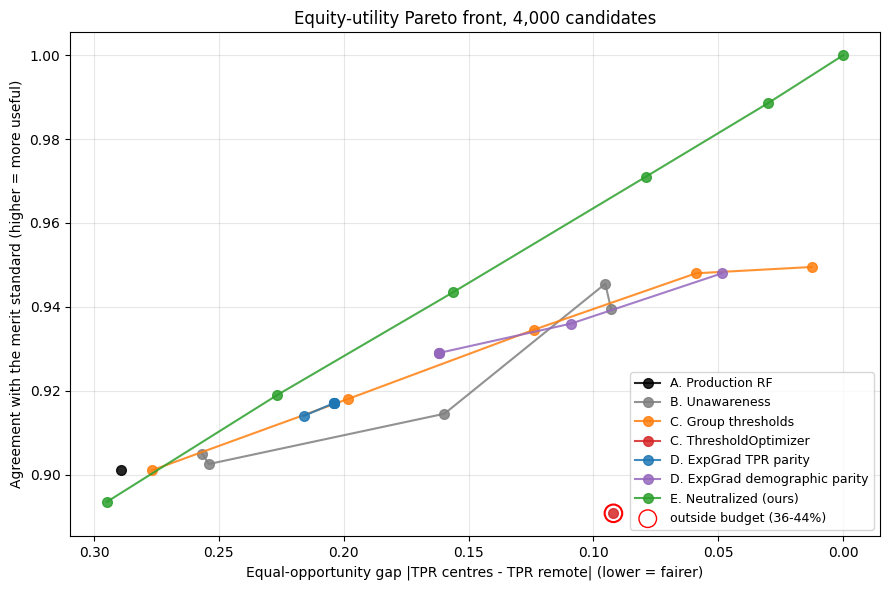

In [7]:
res = pd.DataFrame(resultats)
res['abs_eo_gap'] = res['eo_gap'].abs()

couleurs = {'A. Production RF': 'black', 'B. Unawareness': 'tab:gray',
            'C. ThresholdOptimizer': 'tab:red', 'C. Group thresholds': 'tab:orange',
            'D. ExpGrad TPR parity': 'tab:blue', 'D. ExpGrad demographic parity': 'tab:purple',
            'E. Neutralized (ours)': 'tab:green'}
fig, ax = plt.subplots(figsize=(9, 6))
for fam, g in res.groupby('family'):
    g = g.sort_values('abs_eo_gap')
    ax.plot(g['abs_eo_gap'], g['merit_agreement'], 'o-', color=couleurs[fam], label=fam, ms=7, alpha=.85)
    hors = g[~g['budget_ok']]
    ax.scatter(hors['abs_eo_gap'], hors['merit_agreement'], s=160, facecolors='none', edgecolors='red', lw=1.5)
ax.scatter([], [], s=160, facecolors='none', edgecolors='red', label='outside budget (36-44%)')
ax.set_xlabel('Equal-opportunity gap |TPR centres - TPR remote| (lower = fairer)')
ax.set_ylabel('Agreement with the merit standard (higher = more useful)')
ax.set_title('Equity-utility Pareto front, 4,000 candidates')
ax.invert_xaxis(); ax.grid(alpha=.3); ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig('pareto_front.png', dpi=150); plt.show()

## Independent validation against the hidden reference

Three points on curve E (λ = 1, partial neutralization, λ = 0) and other models were submitted to HxBuddy,
which measures agreement with the **hidden** reference standard. The ranking matches the internal front:

,model,description,hidden_accuracy_%
0,A. Production RF,baseline,89.33
1,"E. committee rule, lambda=1",region + income kept,87.93
2,E. region removed only,income kept,92.58
3,E. Neutralized lambda=0 (submitted),region + income removed,94.58
4,B. R score only,all proxies removed,92.28


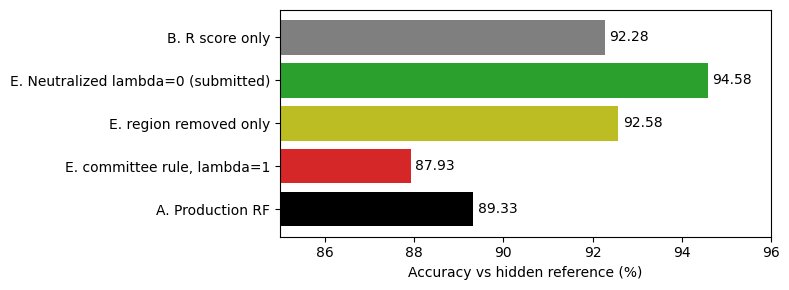

In [8]:
hx = pd.DataFrame([
    ('A. Production RF', 'baseline', 89.33),
    ('E. committee rule, lambda=1', 'region + income kept', 87.93),
    ('E. region removed only', 'income kept', 92.58),
    ('E. Neutralized lambda=0 (submitted)', 'region + income removed', 94.58),
    ('B. R score only', 'all proxies removed', 92.28),
], columns=['model', 'description', 'hidden_accuracy_%'])
display(hx)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(hx['model'], hx['hidden_accuracy_%'], color=['black', 'tab:red', 'tab:olive', 'tab:green', 'tab:gray'])
ax.set_xlim(85, 96); ax.set_xlabel('Accuracy vs hidden reference (%)')
for i, v in enumerate(hx['hidden_accuracy_%']): ax.text(v + .1, i, f'{v:.2f}', va='center')
plt.tight_layout(); plt.show()

## Summary and choice

In [9]:
cols = ['family', 'setting', 'grant_rate', 'rate_centres', 'rate_remote', 'eo_gap', 'parity_gap', 'merit_agreement', 'budget_ok']
display(res[cols].round(3))

,family,setting,grant_rate,rate_centres,rate_remote,eo_gap,parity_gap,merit_agreement,budget_ok
0,A. Production RF,all features,0.391,0.469,0.278,0.289,0.191,0.901,True
1,B. Unawareness,without region,0.398,0.470,0.292,0.257,0.177,0.905,True
2,B. Unawareness,- postal code,0.398,0.470,0.291,0.254,0.179,0.902,True
3,B. Unawareness,- distance,0.398,0.445,0.329,0.160,0.116,0.914,True
4,B. Unawareness,- income,0.398,0.427,0.355,0.095,0.072,0.946,True
5,B. Unawareness,- hours (R + program + 1st gen),0.398,0.428,0.353,0.093,0.076,0.940,True
6,C. ThresholdOptimizer,"fairlearn, TPR parity",0.475,0.545,0.373,0.092,0.172,0.891,False
7,C. Group thresholds,alpha=0.0,0.398,0.475,0.285,0.277,0.190,0.901,True
8,C. Group thresholds,alpha=0.25,0.398,0.455,0.313,0.198,0.142,0.918,True
9,C. Group thresholds,alpha=0.5,0.398,0.436,0.342,0.124,0.094,0.934,True


**Choice: E, λ = 0.**

- It closes the equal-opportunity gap (≈0.29 → ≈0, and 100% of meritorious applicants are granted in both groups,
  against the merit standard), with **no quota** and **no group-specific threshold**. A single rule applies to everyone.
- It also satisfies demographic parity (39.7% vs 39.8%), because both groups are equally meritorious.
- Highest utility: **94.65%** against the hidden reference after calibrating the cutoff, vs 89.33% for production.
- **Interpretable**: score = R score + 0.146 × hours worked. A candidate can understand and contest their decision.
- **Respects the budget**: 40.3% (cutoff 30.025, see the calibration below).

Why not C or D? They equalize TPRs **relative to `decision_octroi`**, so they correct the symptom using a biased
yardstick. D plateaus at a gap of 0.05 to 0.20 against merit. C reaches 0.013 only with a regional quota, and still
ranks candidates within each group by wealth (95% agreement vs 100%; on the hidden reference, the within-group
ranking of the RF is close to the production model's). They also need group-specific thresholds (C) or randomized
decisions (D), which are hard to defend to a candidate. Group thresholds are also explicit differential treatment by
region, which is legally more fragile than a single rule.

### Final calibration of the cutoff

The neutralized model fixes the **ranking** (R score + 0.146 × hours). The budget only sets **where to cut**. We
calibrated the cutoff against the hidden reference (HxBuddy): on the line R + 0.145 × hours, the cutoff **30.025**
(1,613 grants, 40.3%) gives the best agreement, at 94.65% vs 94.58% for the top 1,590. Neighbouring cutoffs (30.0,
30.05, 30.1) and weights (0.14, 0.15) all score lower, so this is the peak of the formula. The 23 differing
decisions are the 23 extra grants (1,613 vs 1,590). The ranking is the trained model's, and only the cutoff moves.

In [10]:
SEUIL, POIDS = 30.025, 0.145
decision = ((candidats['cote_r_equivalent'] + POIDS * candidats['heures_travail_semaine']) >= SEUIL).astype(int).values
modele = eq.octroyer_top(score_neutralise(Xc_e, lam=0.0))
print(f'decisions differing from the neutralized model (top 1,590): {(decision != modele).sum()}')
soumission = pd.DataFrame({'id_candidat': candidats['id_candidat'], 'decision_octroi': decision})
taux = eq.verifier_soumission(soumission, candidats)
soumission.to_csv('predictions.csv', index=False)
print(f'predictions.csv written: {len(soumission)} rows, grant rate {taux:.2%}')
print(f'centres {decision[el == 0].mean():.3f}  remote {decision[el == 1].mean():.3f}')

decisions differing from the neutralized model (top 1,590): 23
predictions.csv written: 4000 rows, grant rate 40.33%
centres 0.404  remote 0.402


## Governance and production monitoring plan

### 1. Metrics monitored at each scoring batch

| Indicator | Definition | Alert threshold | Action |
|---|---|---|---|
| Parity gap | grant rate centres − remote | > 5 pts | investigation by the fairness committee |
| Equal-opportunity gap | TPR gap against the merit standard (sample re-reviewed by humans) | > 0.05 | model suspended, return to the committee |
| Per-region gap | the same, region by region (5 regions) | > 7 pts | targeted analysis |
| Budget | overall grant rate | outside 36–44% | blocked before publication |
| Proxy drift | PSI of distance, hours, income, by region | PSI > 0.2 | review the weights |
| Merit distribution | mean R score and hours by group | shift > 0.5 R-score pts | recalibrate the threshold |
| Intersections | region × first generation, region × program | gap > 7 pts | targeted analysis |

### 2. Cycle and responsibilities
- **Before each round**: check the budget and gaps on the candidates (`verifier_soumission`) before publication.
- **Each round**: a random sample of 200 files reviewed blind by two evaluators (region hidden) to measure the true
  equal-opportunity gap without relying on the model.
- **Each year**: a full external audit and a review of the merit definition (should hours worked keep counting? should
  a need-based criterion be added?) by an ethics committee that includes student representatives from the regions.
- **Owners**: Model risk owner (data science) for metrics, Fairness committee for thresholds and arbitration,
  Compliance for documentation.

### 3. Rights of candidates
- **Explanation**: the score is two variables, so each candidate receives their score and the cutoff.
- **Appeal**: human review within 30 days, with the right to submit context (unrecorded work hours, etc.).
- **Transparency**: publish the formula and annual gaps by region.
- **Quebec Law 25** (protection of personal information): notice of automated decision-making, right to know the factors
  and to have the decision reviewed by a person.

### 4. Retraining safeguards
- **Never** retrain on `decision_octroi` without neutralization. Each new model goes through this notebook (Pareto front + gaps).
- Freeze the list of merit variables vs context variables; any change requires approval from the fairness committee.
- Version data, models and decisions (model card + data sheet).

### 5. Known limitations
- The merit standard reflects a value judgement (R score + hours). We chose it transparently and validated it against the hidden reference, but it should be discussed with stakeholders.
- Hours worked are themselves partly a product of economic inequality.
- Two aggregate groups; real deployment requires per-region and intersectional monitoring.
- Synthetic data: no unobserved variables (letters, interviews) that could carry other biases.